# Data Scaling & Empirical Learning Curve Analysis

1. **MixUp-Multiplikator (`mixtures_per_pair`):** $M \in \{2, 5, 10, 20, 40, 80\}$

2. **Anzahl der Basis-Artikelpaare (`num_train_article_pairs`):** $F \in \{10\%, 25\%, 50\%, 75\%, 100\%\}$


In [1]:
import os, sys

def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, 'data')) and os.path.exists(os.path.join(p, 'results')):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser('~/Documents/Master Thesis'))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
import os
import sys
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

start_dir = os.getcwd()
while not (os.path.exists("data") and os.path.exists("scripts")):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():  # Root des Dateisystems erreicht
        os.chdir(start_dir)
    os.chdir("..")

print(f"Projekt-Root: {os.getcwd()}")

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 300
})

RESULTS_DIR = "results/experiments/data_scaling"
SUMMARY_CSV = os.path.join(RESULTS_DIR, "scaling_summary.csv")
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Results-Verzeichnis: {RESULTS_DIR}")
print(f"Plots-Verzeichnis:   {PLOTS_DIR}")

Projekt-Root: /Users/fietescheel/Documents/Master Thesis
Results-Verzeichnis: results/experiments/data_scaling
Plots-Verzeichnis:   results/experiments/data_scaling/plots


## 1. Daten laden und tabellarische Übersicht


In [2]:
if os.path.exists(SUMMARY_CSV):
    df = pd.read_csv(SUMMARY_CSV)
else:
    # Fallback: Direkt aus den JSON-Dateien einlesen
    json_files = glob.glob(os.path.join(RESULTS_DIR, "*_metrics.json"))
    records = []
    for jf in json_files:
        try:
            with open(jf, "r", encoding="utf-8") as f:
                records.append(json.load(f))
        except Exception as e:
            print(f"Fehler beim Lesen von {jf}: {e}")
    df = pd.DataFrame(records)

if not df.empty:
    display_cols = [
        "experiment_name", "experiment_group", "num_train_article_pairs",
        "mixtures_per_pair", "total_train_samples", "test_mse", "test_mae", "test_r2", "test_binary_acc", "training_time_seconds"
    ]
    df_display = df[[c for c in display_cols if c in df.columns]].sort_values(by=["experiment_group", "total_train_samples"])
    display(df_display)
else:
    print("Noch keine Evaluations-Ergebnisse gefunden. Bitte zuerst die SLURM-Experimente ausführen.")

,experiment_name,experiment_group,num_train_article_pairs,mixtures_per_pair,total_train_samples,test_mse,test_mae,test_r2,test_binary_acc,training_time_seconds
0,scale_mixtures_m2,mixtures_scaling,505,2,1010,0.06599,0.20144,0.15239,72.27,8.48
1,scale_mixtures_m5,mixtures_scaling,505,5,2525,0.05520,0.18061,0.29104,78.36,25.16
2,scale_mixtures_m10,mixtures_scaling,505,10,5050,0.05773,0.18705,0.25854,73.91,16.65
3,scale_mixtures_m20,mixtures_scaling,505,20,10100,0.04181,0.15794,0.46294,81.41,54.72
4,scale_mixtures_m40,mixtures_scaling,505,40,20200,0.02637,0.11506,0.66128,85.55,108.80
5,scale_mixtures_m80,mixtures_scaling,505,80,40400,0.02075,0.09584,0.73354,87.58,293.80
6,scale_mixtures_m160,mixtures_scaling,505,160,80800,0.01928,0.09137,0.75238,87.19,409.43
7,scale_mixtures_m320,mixtures_scaling,505,320,161600,0.01939,0.08797,0.75090,88.05,741.39
8,scale_pairs_f010,pairs_scaling,50,20,1000,0.06458,0.20062,0.17049,71.56,8.30
9,scale_pairs_f025,pairs_scaling,126,20,2520,0.06255,0.19951,0.19655,69.14,7.40


## 2. Dimension 1: MixUp-Multiplikator Skalierung (`mixtures_per_pair`)


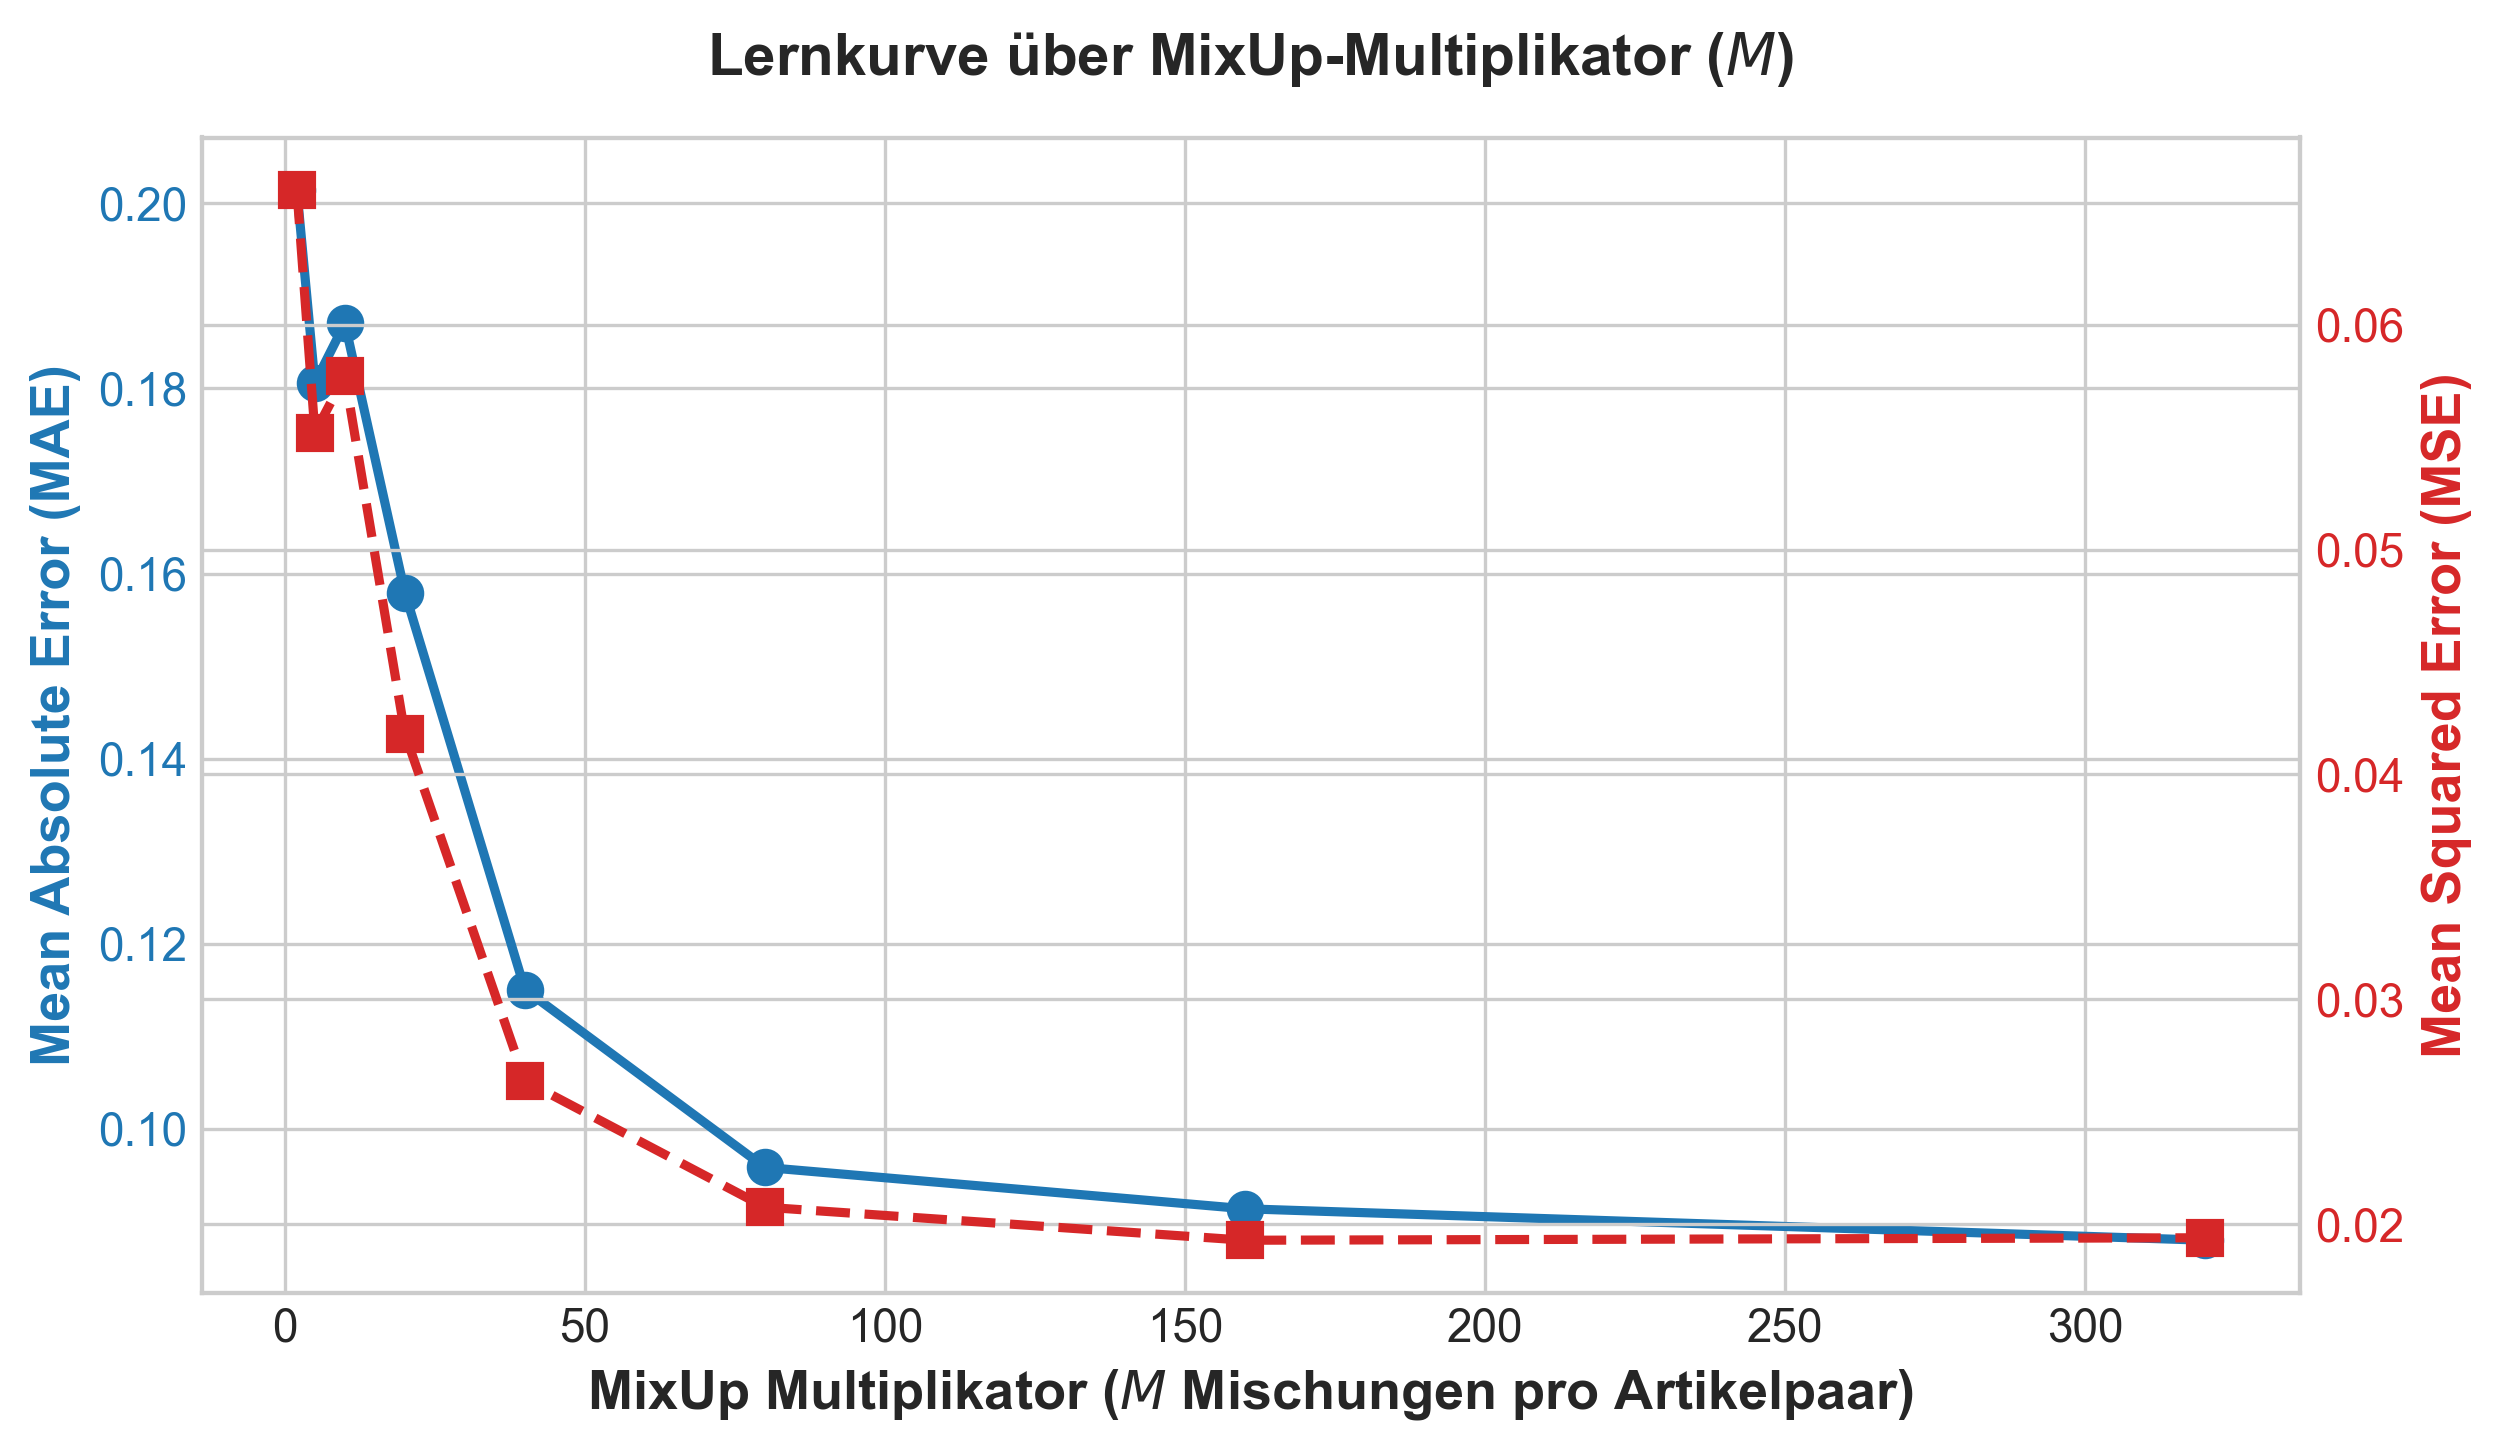

In [3]:
df_mix = df[df["experiment_group"] == "mixtures_scaling"].sort_values("mixtures_per_pair")

if not df_mix.empty:
    fig, ax1 = plt.subplots(figsize=(8.5, 5))

    color_mae = "#1f77b4"
    color_mse = "#d62728"

    ax1.plot(df_mix["mixtures_per_pair"], df_mix["test_mae"], marker='o', markersize=8, color=color_mae, linewidth=2.2, label="Test MAE")
    ax1.set_xlabel("MixUp Multiplikator ($M$ Mischungen pro Artikelpaar)", fontweight='bold')
    ax1.set_ylabel("Mean Absolute Error (MAE)", color=color_mae, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_mae)

    ax2 = ax1.twinx()
    ax2.plot(df_mix["mixtures_per_pair"], df_mix["test_mse"], marker='s', markersize=8, linestyle='--', color=color_mse, linewidth=2.2, label="Test MSE")
    ax2.set_ylabel("Mean Squared Error (MSE)", color=color_mse, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_mse)

    plt.title("Lernkurve über MixUp-Multiplikator ($M$)", pad=15, fontweight='bold')
    fig.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "mixup_multiplier_learning_curve.png"), dpi=300)
    plt.show()
else:
    print("Keine Daten für 'mixtures_scaling' vorhanden.")

## 3. Dimension 2: Basis-Artikelpaare Skalierung (`num_train_article_pairs`)


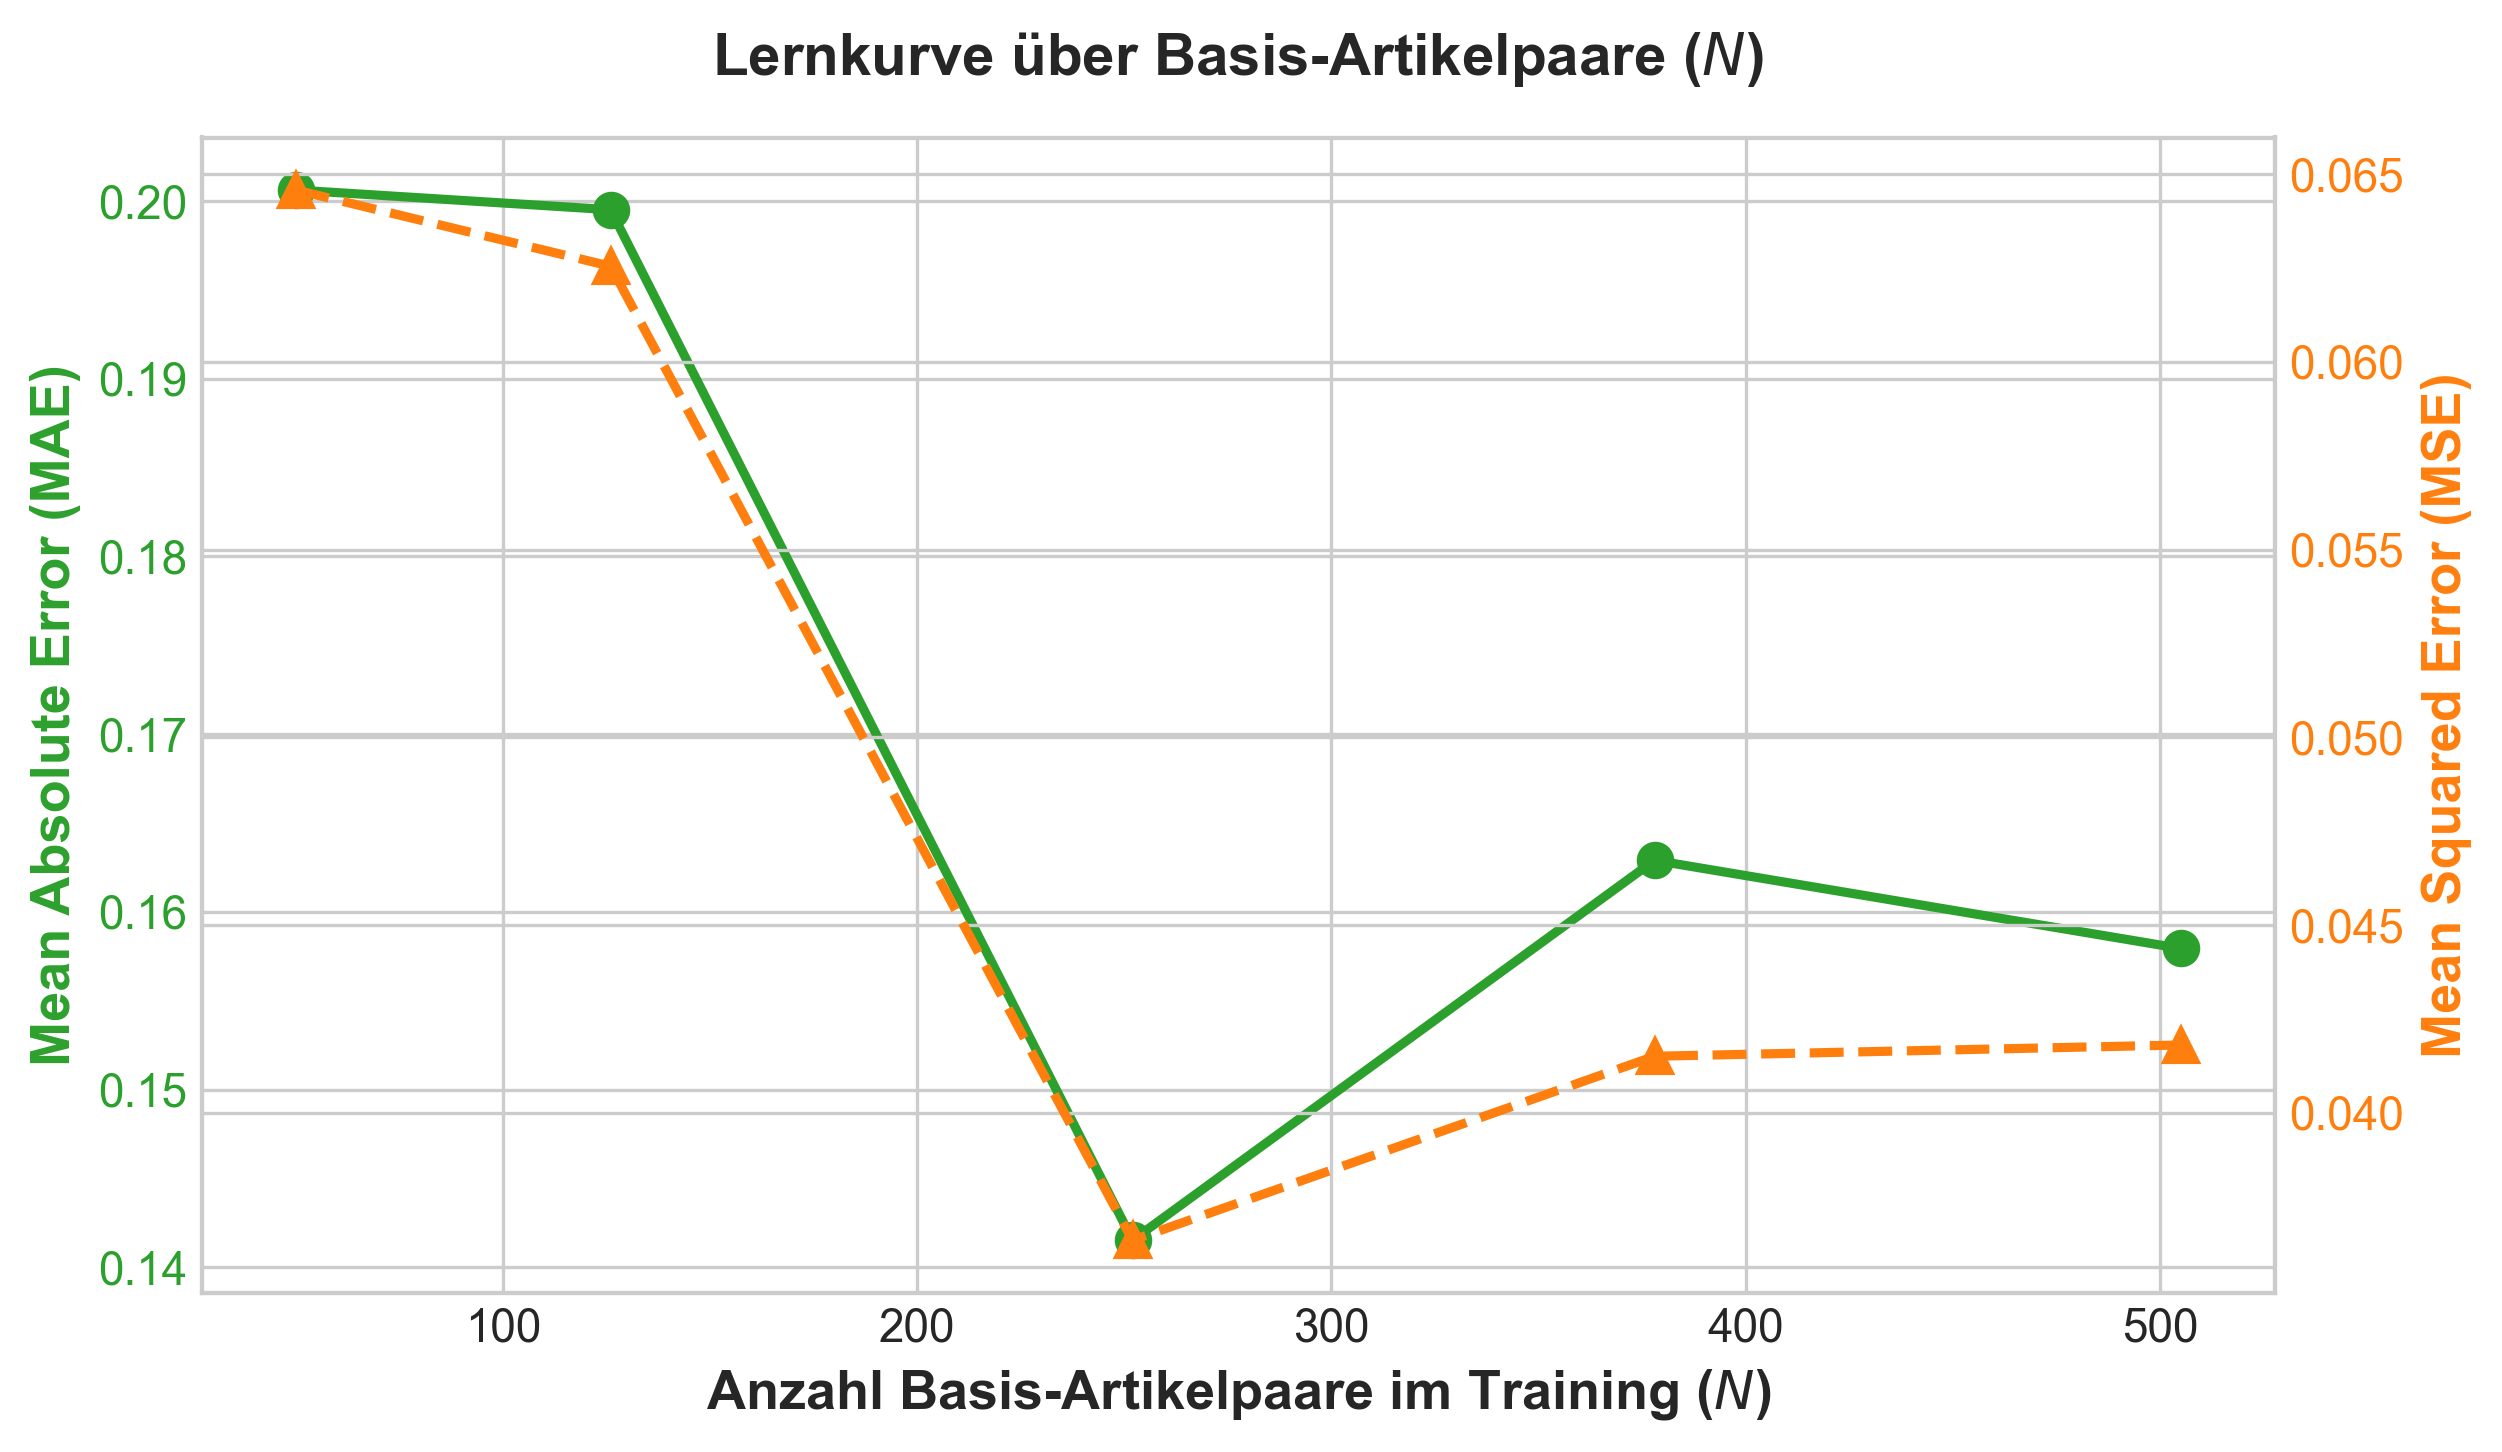

In [4]:
df_pairs = df[df["experiment_group"] == "pairs_scaling"].sort_values("num_train_article_pairs")

if not df_pairs.empty:
    fig, ax1 = plt.subplots(figsize=(8.5, 5))

    color_mae = "#2ca02c"
    color_mse = "#ff7f0e"

    ax1.plot(df_pairs["num_train_article_pairs"], df_pairs["test_mae"], marker='o', markersize=8, color=color_mae, linewidth=2.2, label="Test MAE")
    ax1.set_xlabel("Anzahl Basis-Artikelpaare im Training ($N$)", fontweight='bold')
    ax1.set_ylabel("Mean Absolute Error (MAE)", color=color_mae, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_mae)

    ax2 = ax1.twinx()
    ax2.plot(df_pairs["num_train_article_pairs"], df_pairs["test_mse"], marker='^', markersize=8, linestyle='--', color=color_mse, linewidth=2.2, label="Test MSE")
    ax2.set_ylabel("Mean Squared Error (MSE)", color=color_mse, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_mse)

    plt.title("Lernkurve über Basis-Artikelpaare ($N$)", pad=15, fontweight='bold')
    fig.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "article_pairs_learning_curve.png"), dpi=300)
    plt.show()
else:
    print("Keine Daten für 'pairs_scaling' vorhanden.")

## 4. Bestimmtheitsmaß ($R^2$) & Korrelationen über die Datenmenge


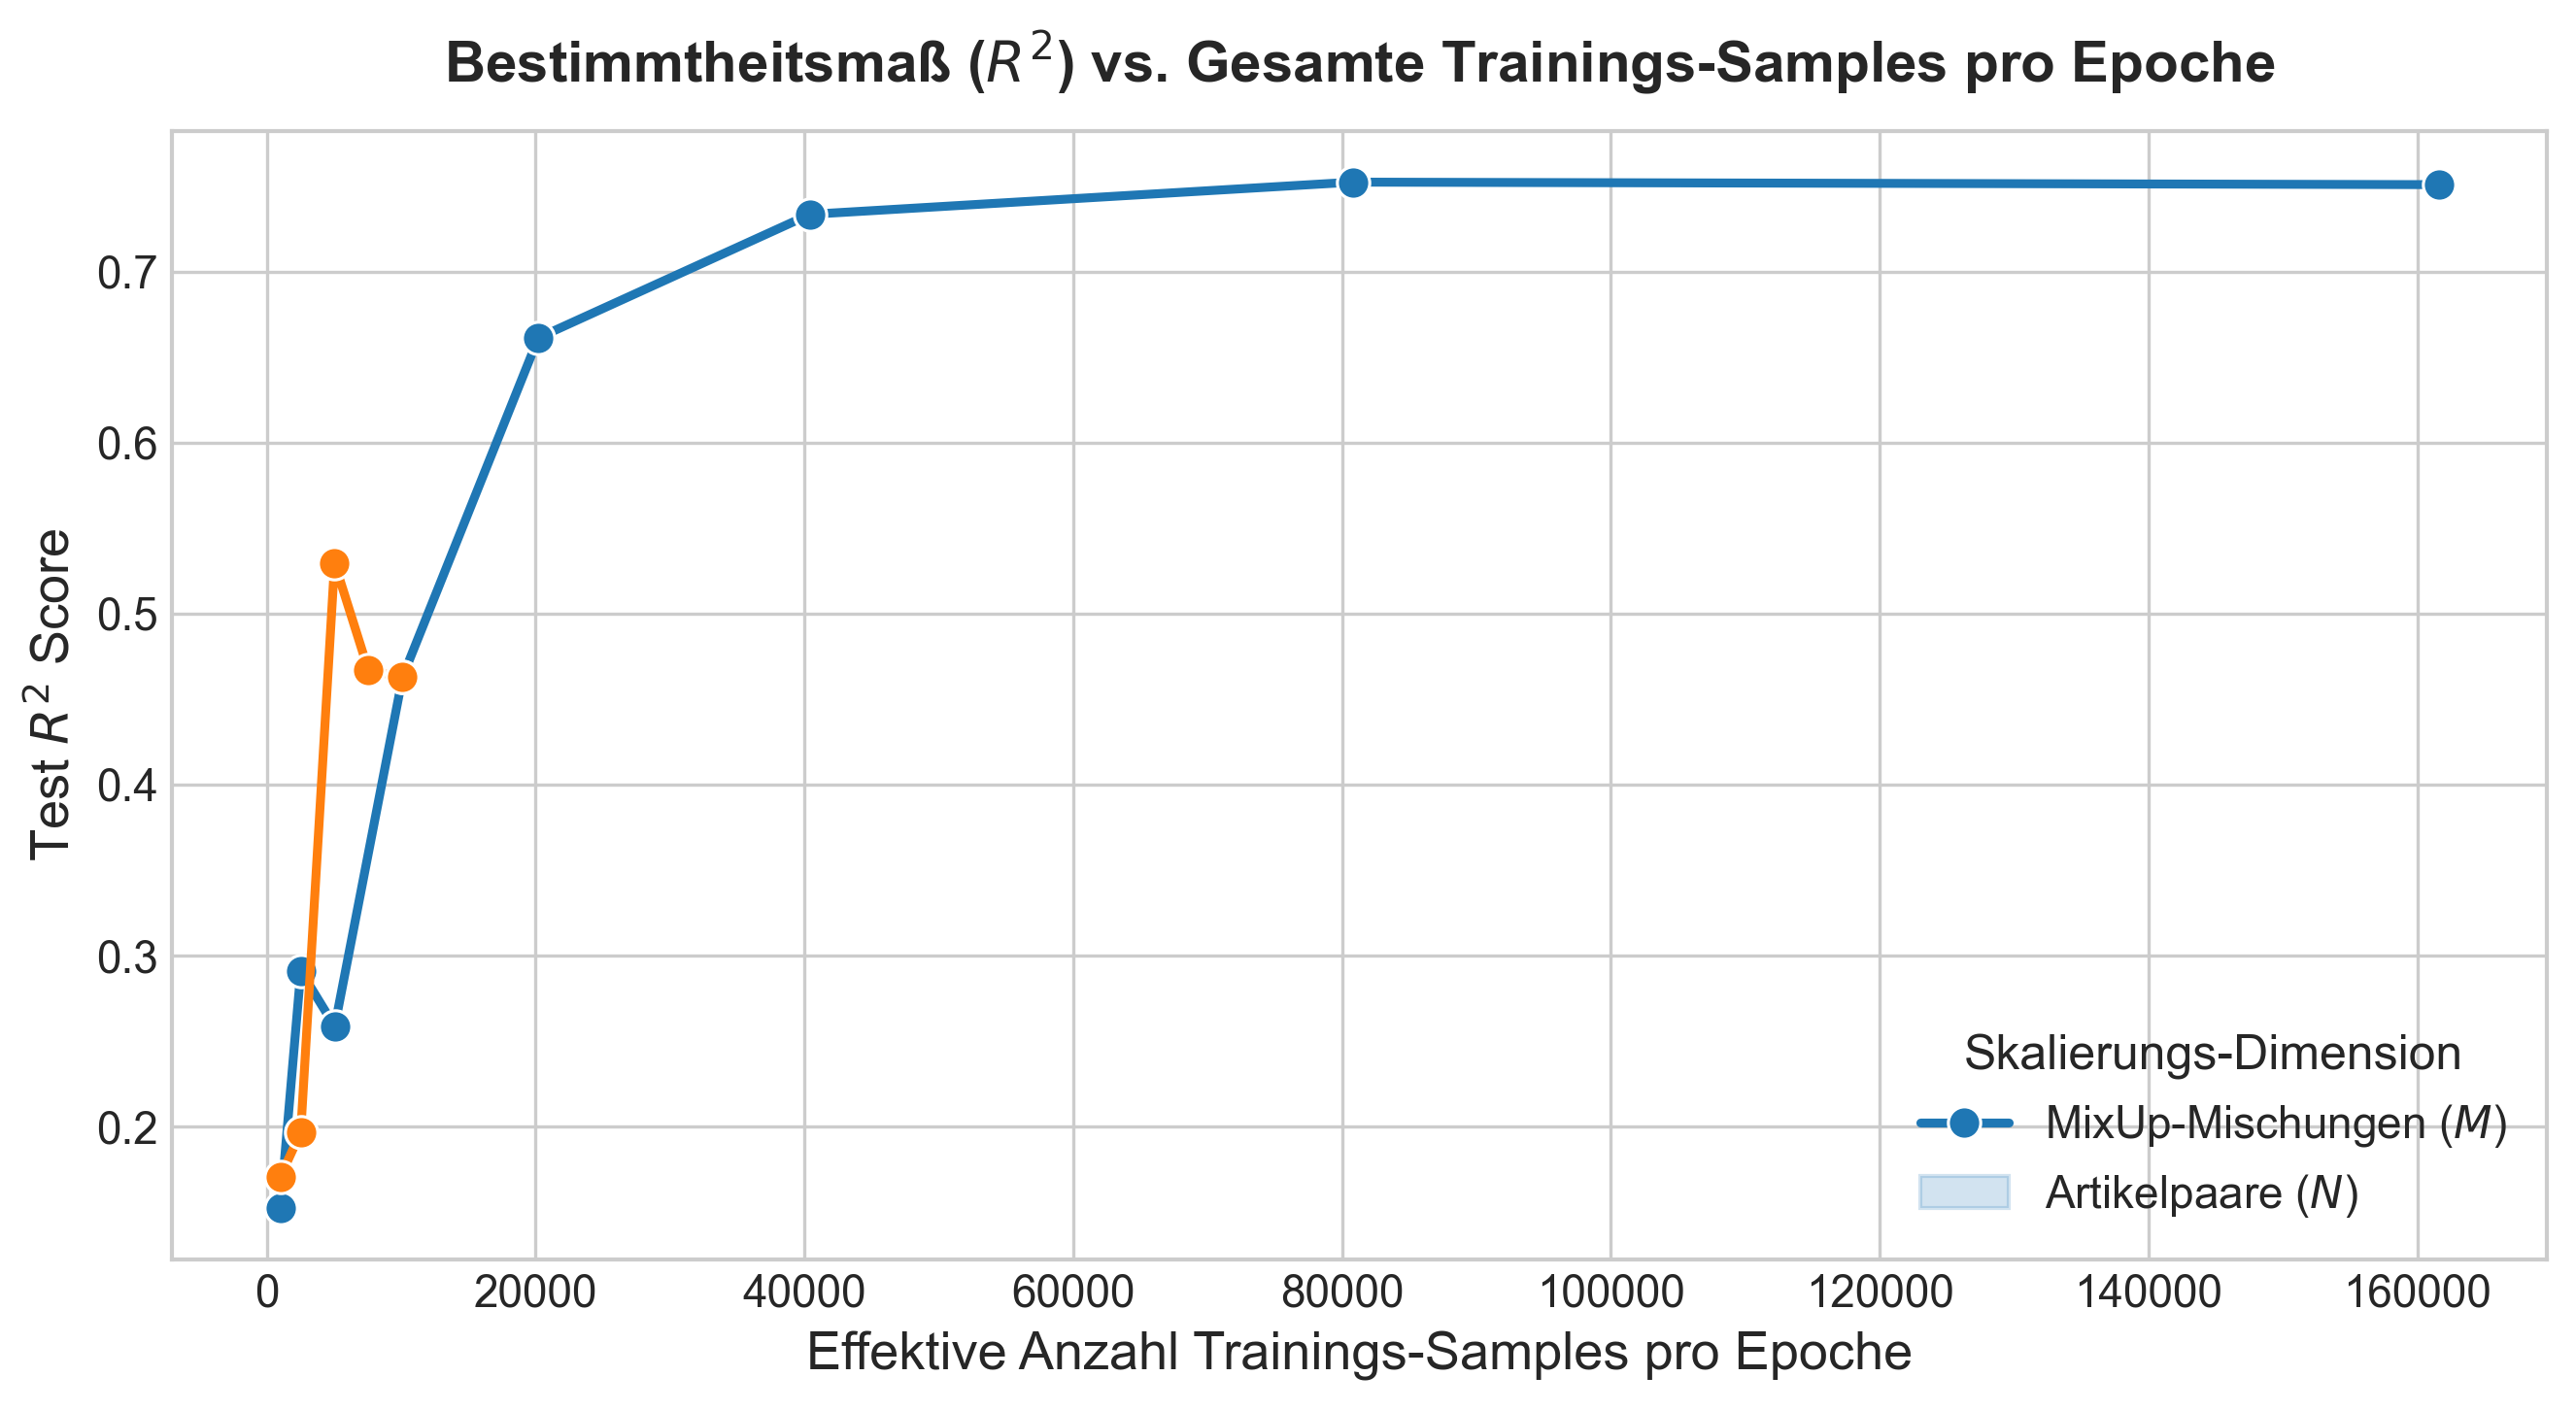

In [5]:
if not df.empty:
    plt.figure(figsize=(9, 5))
    sns.lineplot(data=df, x="total_train_samples", y="test_r2", hue="experiment_group", marker='o', markersize=8, linewidth=2.2)
    plt.title("Bestimmtheitsmaß ($R^2$) vs. Gesamte Trainings-Samples pro Epoche", pad=12, fontweight='bold')
    plt.xlabel("Effektive Anzahl Trainings-Samples pro Epoche")
    plt.ylabel("Test $R^2$ Score")
    plt.legend(title="Skalierungs-Dimension", labels=["MixUp-Mischungen ($M$)", "Artikelpaare ($N$)"])
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "r2_vs_total_samples.png"), dpi=300)
    plt.show()

## 5. Rechenaufwand vs. Performance-Gewinn (Effizienzanalyse)


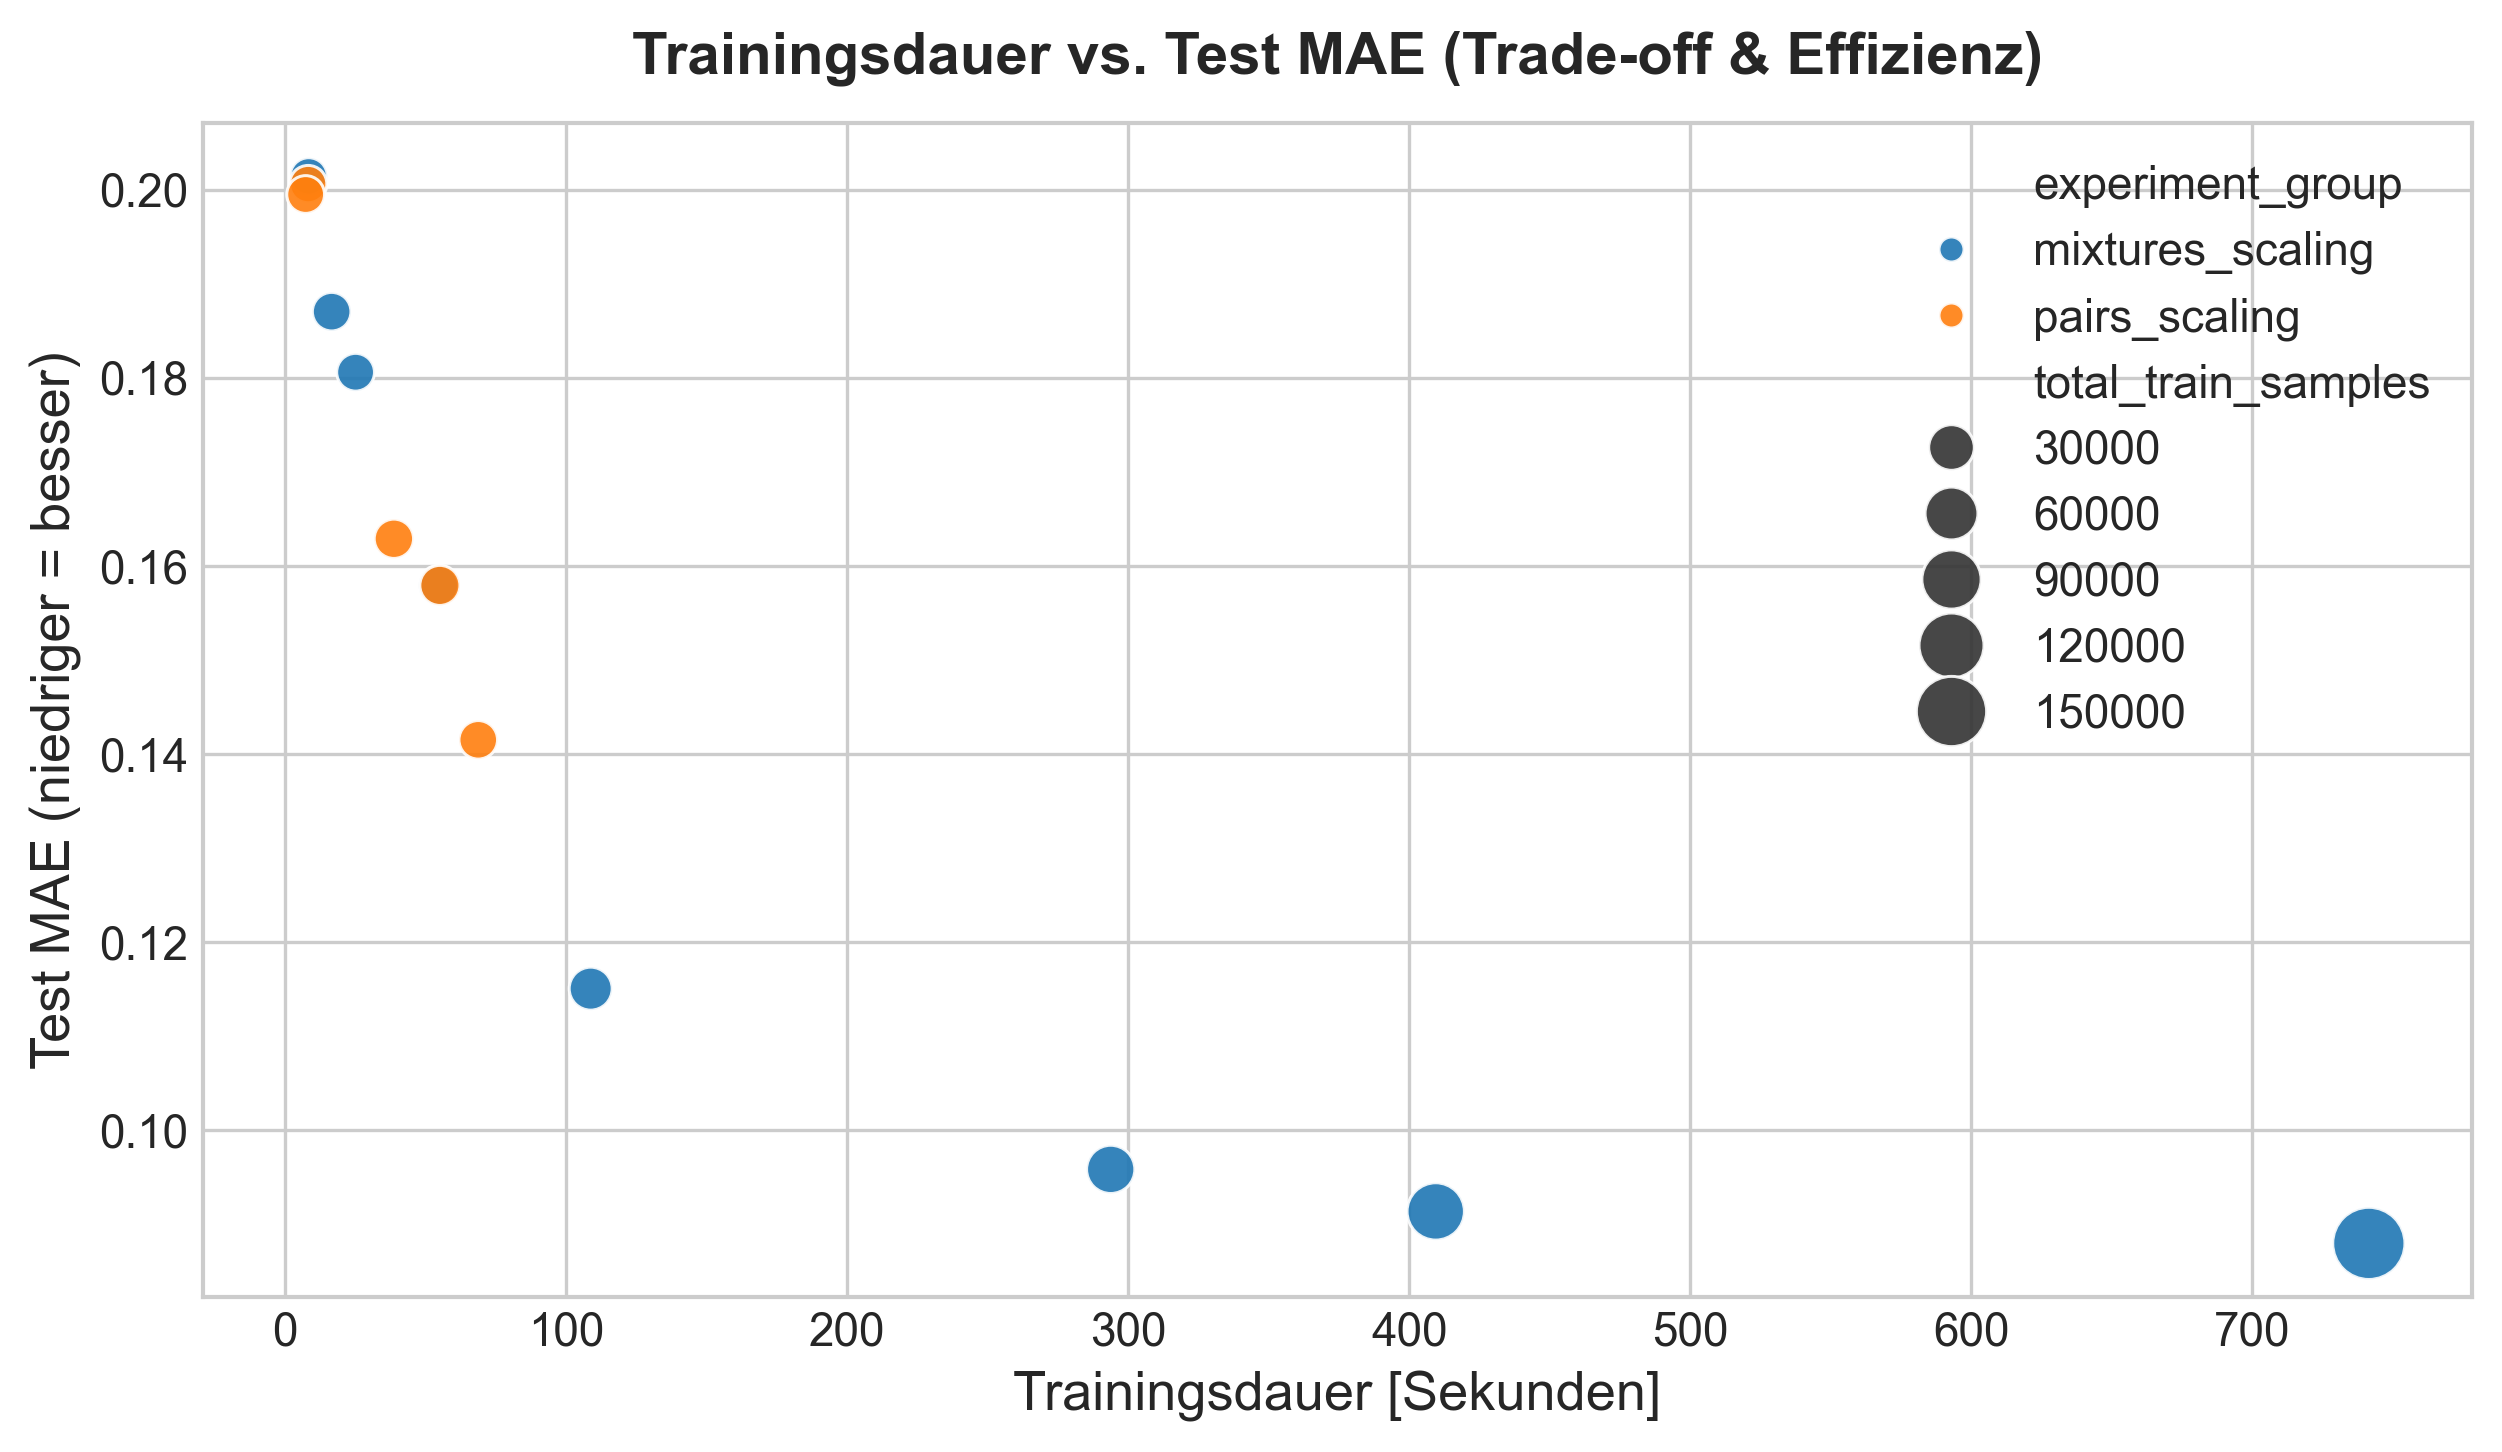

In [6]:
if not df.empty:
    plt.figure(figsize=(8.5, 5))
    sns.scatterplot(
        data=df,
        x="training_time_seconds",
        y="test_mae",
        hue="experiment_group",
        size="total_train_samples",
        sizes=(80, 300),
        alpha=0.9
    )
    plt.title("Trainingsdauer vs. Test MAE (Trade-off & Effizienz)", pad=12, fontweight='bold')
    plt.xlabel("Trainingsdauer [Sekunden]")
    plt.ylabel("Test MAE (niedriger = besser)")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "training_time_vs_mae.png"), dpi=300)
    plt.show()

# 6. Zero-Shot Out-of-Domain Evaluation (Lebenshilfe Gold-Standard)


In [7]:
LH_SUMMARY_CSV = os.path.join(RESULTS_DIR, "scaling_lh_summary.csv")

if os.path.exists(LH_SUMMARY_CSV):
    lh_df = pd.read_csv(LH_SUMMARY_CSV)
    display_cols = [
        "experiment_name", "experiment_group", "mixtures_per_pair", "train_fraction",
        "lh_mean_as", "lh_mean_ls", "lh_delta", "lh_pairwise_acc", "lh_binary_acc", "lh_auc", "lh_mae"
    ]
    display(lh_df[[c for c in display_cols if c in lh_df.columns]].sort_values(by=["experiment_group", "lh_delta"], ascending=[True, False]))
else:
    print("Lebenshilfe-Summary noch nicht vorhanden.")

,experiment_name,experiment_group,mixtures_per_pair,train_fraction,lh_mean_as,lh_mean_ls,lh_delta,lh_pairwise_acc,lh_binary_acc,lh_auc,lh_mae
5,scale_mixtures_m80,mixtures_scaling,80,1.00,0.0646,0.7760,0.7114,97.30,97.30,99.96,0.1443
7,scale_mixtures_m320,mixtures_scaling,320,1.00,0.0822,0.7825,0.7003,97.30,97.30,99.89,0.1498
6,scale_mixtures_m160,mixtures_scaling,160,1.00,0.0962,0.7777,0.6815,97.30,97.30,99.96,0.1593
4,scale_mixtures_m40,mixtures_scaling,40,1.00,0.1245,0.6918,0.5673,97.30,95.95,99.82,0.2163
3,scale_mixtures_m20,mixtures_scaling,20,1.00,0.1420,0.6738,0.5318,97.30,93.24,99.60,0.2341
1,scale_mixtures_m5,mixtures_scaling,5,1.00,0.1347,0.6222,0.4876,97.30,90.54,96.90,0.2562
2,scale_mixtures_m10,mixtures_scaling,10,1.00,0.1469,0.5208,0.3738,97.30,85.14,96.31,0.3131
0,scale_mixtures_m2,mixtures_scaling,2,1.00,0.2358,0.5663,0.3305,83.78,82.43,85.14,0.3347
12,scale_pairs_f100,pairs_scaling,20,1.00,0.1420,0.6738,0.5318,97.30,93.24,99.60,0.2341
10,scale_pairs_f050,pairs_scaling,20,0.50,0.1438,0.6656,0.5218,97.30,91.89,99.45,0.2391


## 6.1 Lebenshilfe Dimension 1: MixUp-Multiplikator ($)


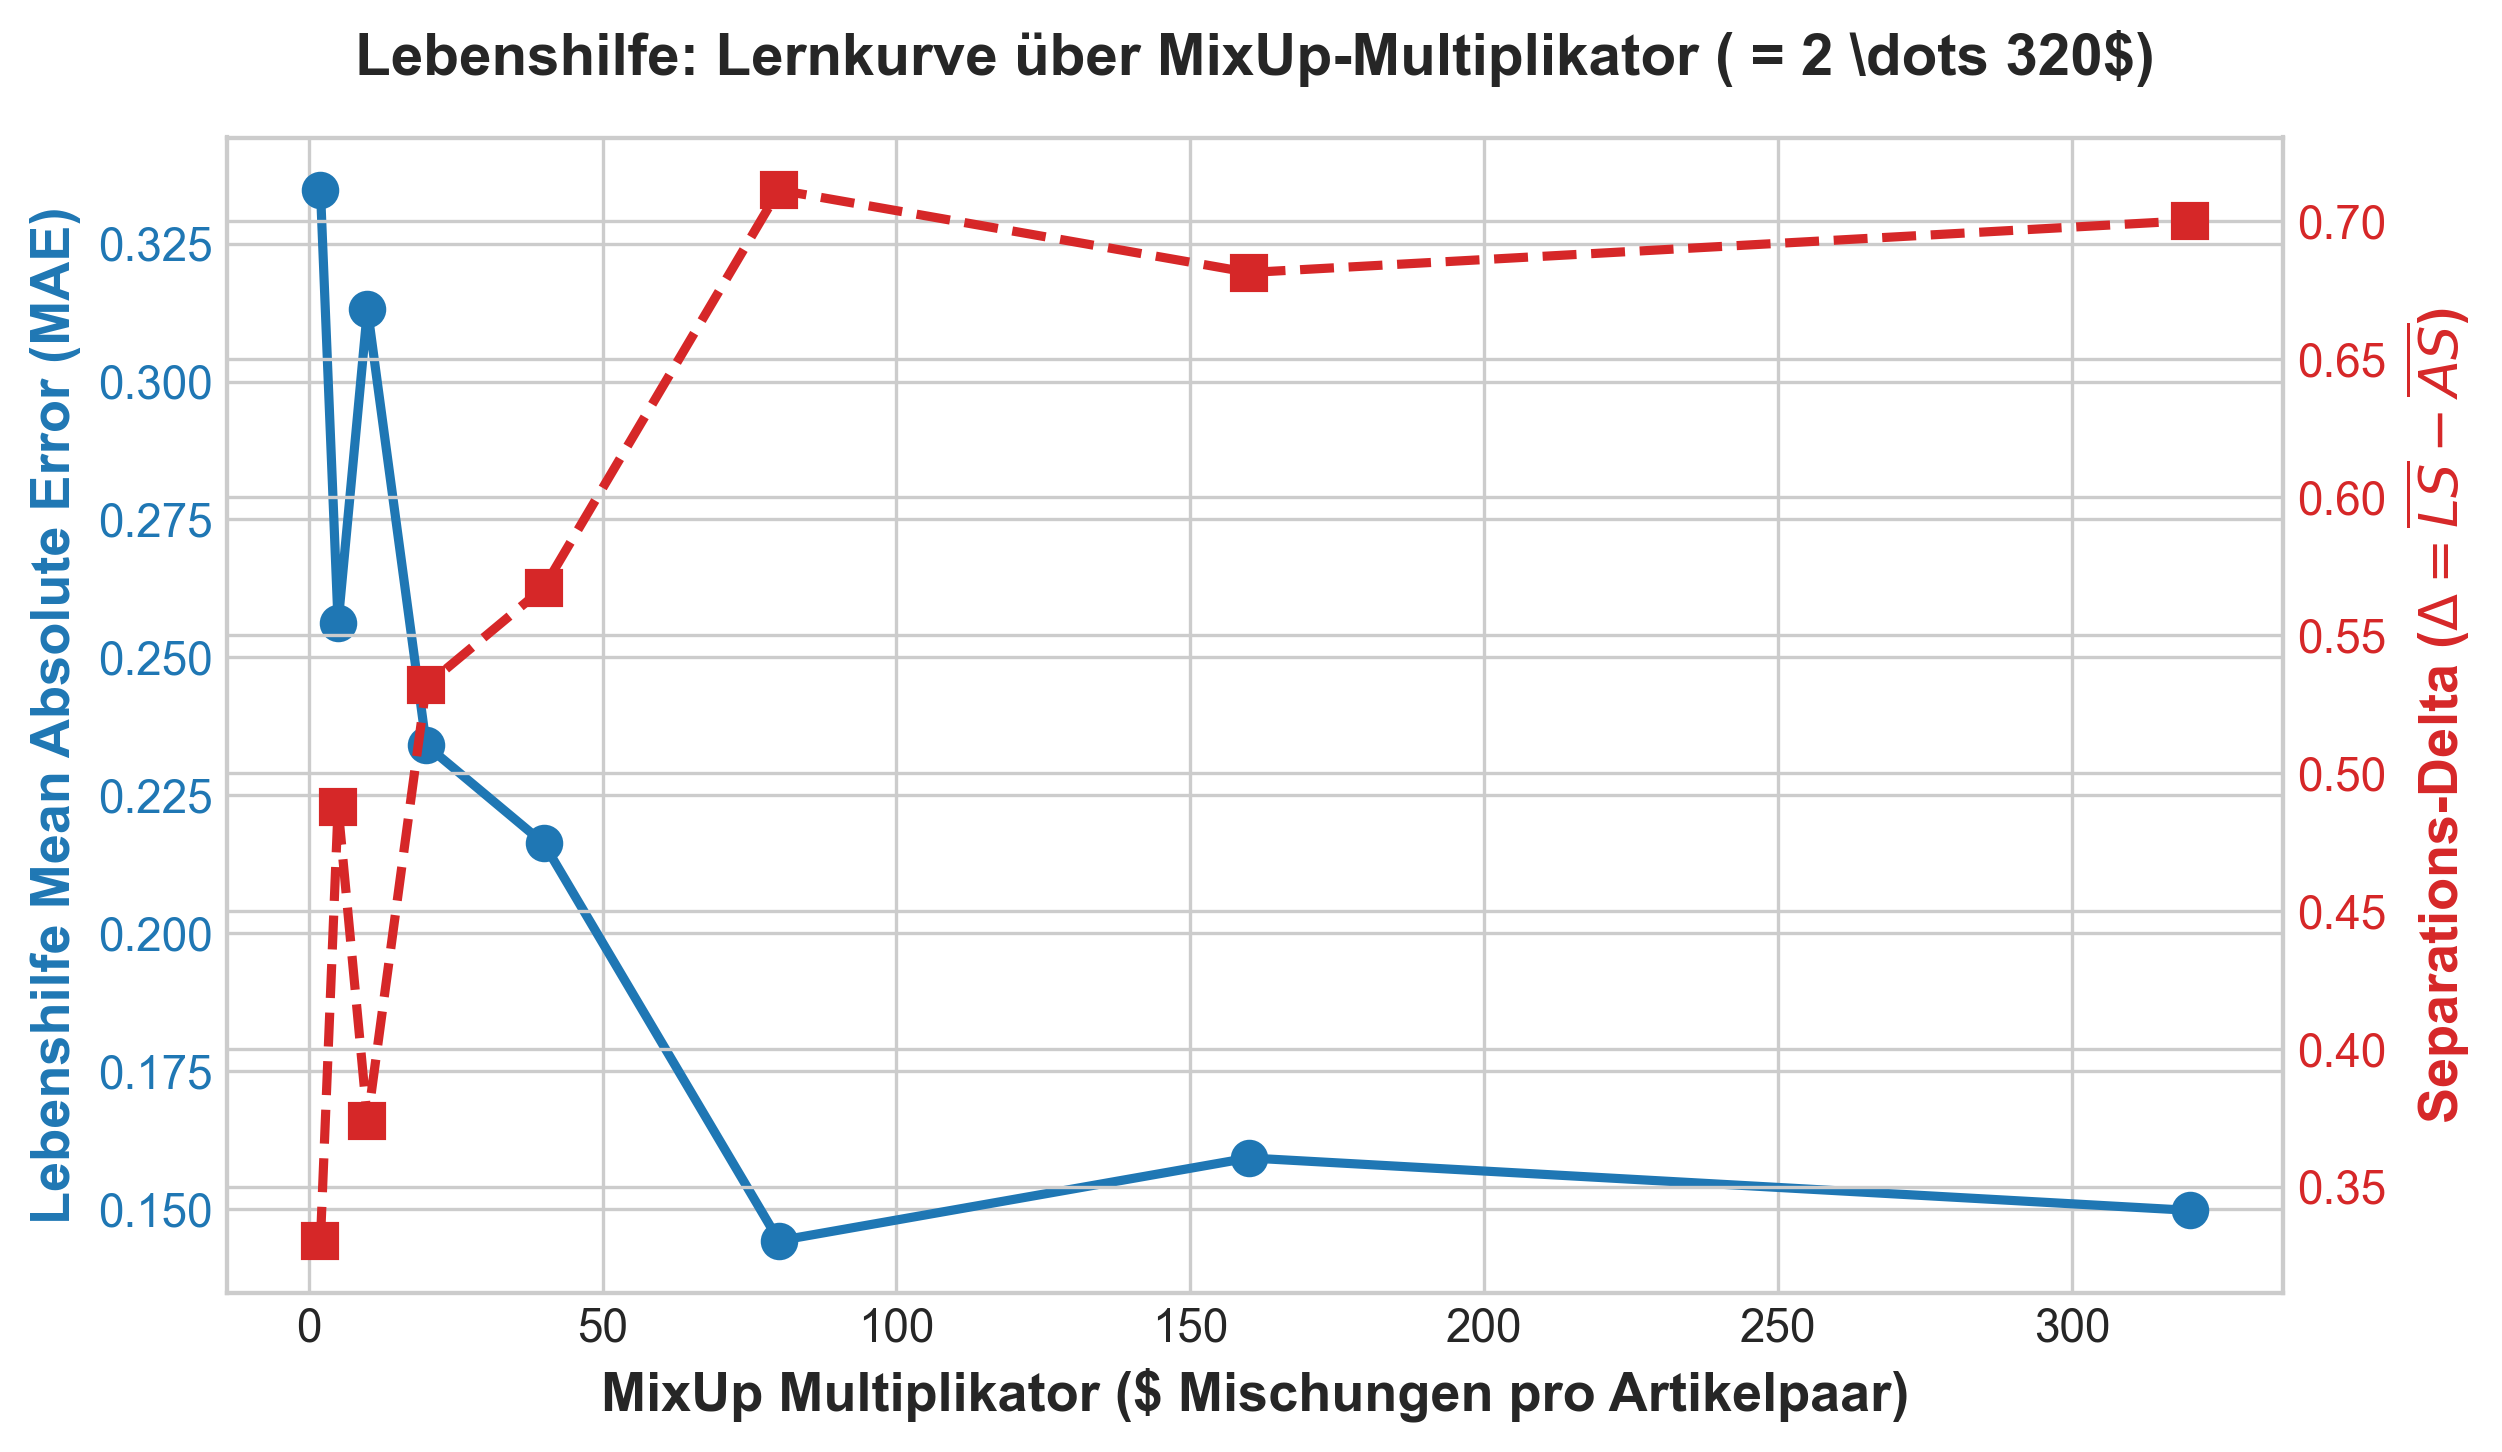

In [8]:
df_mix = df.merge(pd.read_csv(LH_SUMMARY_CSV), on="experiment_name", suffixes=("", "_lh")) if os.path.exists(LH_SUMMARY_CSV) else pd.DataFrame()
df_mix = df_mix[df_mix["experiment_group"] == "mixtures_scaling"].sort_values("mixtures_per_pair")

if not df_mix.empty:
    fig, ax1 = plt.subplots(figsize=(8.5, 5))
    color_mae = "#1f77b4"
    color_delta = "#d62728"

    ax1.plot(df_mix["mixtures_per_pair"], df_mix["lh_mae"], marker='o', markersize=8, color=color_mae, linewidth=2.2, label="Lebenshilfe MAE")
    ax1.set_xlabel("MixUp Multiplikator ($ Mischungen pro Artikelpaar)", fontweight='bold')
    ax1.set_ylabel("Lebenshilfe Mean Absolute Error (MAE)", color=color_mae, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_mae)

    ax2 = ax1.twinx()
    ax2.plot(df_mix["mixtures_per_pair"], df_mix["lh_delta"], marker='s', markersize=8, linestyle='--', color=color_delta, linewidth=2.2, label="Separation Delta")
    ax2.set_ylabel(r"Separations-Delta ($\Delta = \overline{LS} - \overline{AS}$)", color=color_delta, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_delta)

    plt.title(r"Lebenshilfe: Lernkurve über MixUp-Multiplikator ( = 2 \dots 320$)", pad=15, fontweight='bold')
    fig.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "lh_mixup_multiplier_learning_curve.png"), dpi=300)
    plt.show()

## 6.2 Lebenshilfe Dimension 2: Basis-Artikelpaare ($)


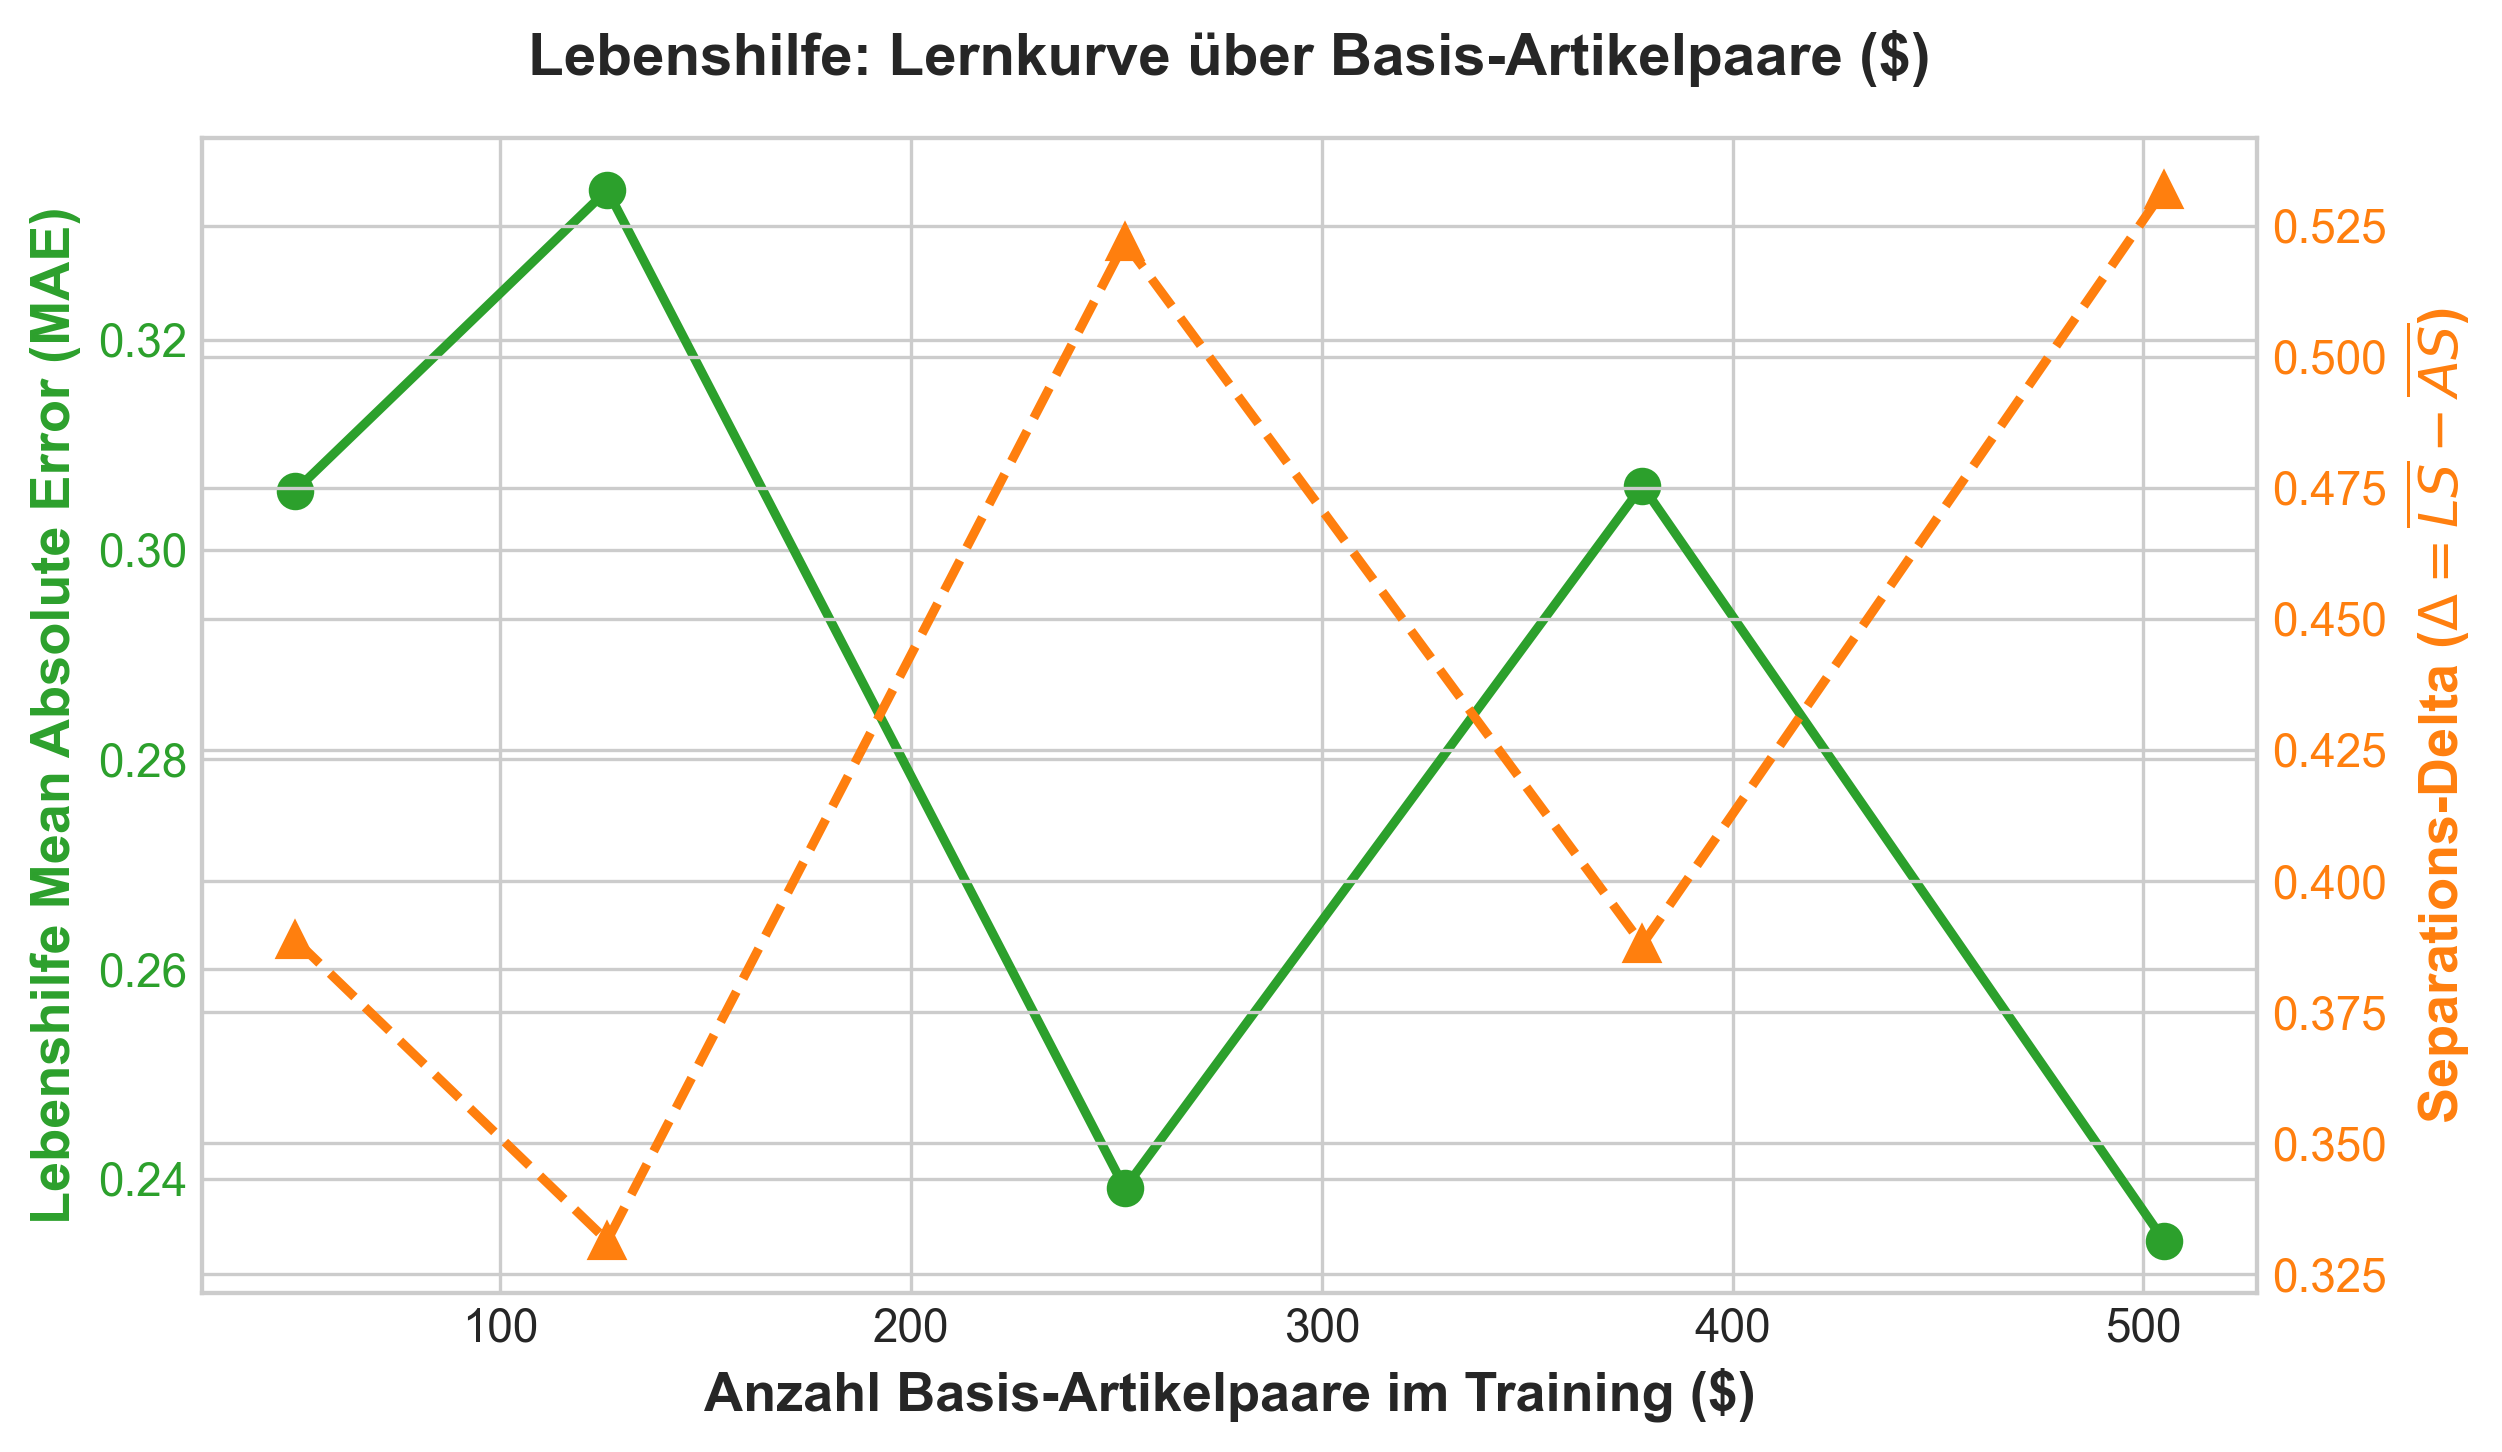

In [9]:
df_pairs = df.merge(pd.read_csv(LH_SUMMARY_CSV), on="experiment_name", suffixes=("", "_lh")) if os.path.exists(LH_SUMMARY_CSV) else pd.DataFrame()
df_pairs = df_pairs[df_pairs["experiment_group"] == "pairs_scaling"].sort_values("num_train_article_pairs")

if not df_pairs.empty:
    fig, ax1 = plt.subplots(figsize=(8.5, 5))
    color_mae = "#2ca02c"
    color_delta = "#ff7f0e"

    ax1.plot(df_pairs["num_train_article_pairs"], df_pairs["lh_mae"], marker='o', markersize=8, color=color_mae, linewidth=2.2, label="Lebenshilfe MAE")
    ax1.set_xlabel("Anzahl Basis-Artikelpaare im Training ($)", fontweight='bold')
    ax1.set_ylabel("Lebenshilfe Mean Absolute Error (MAE)", color=color_mae, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_mae)

    ax2 = ax1.twinx()
    ax2.plot(df_pairs["num_train_article_pairs"], df_pairs["lh_delta"], marker='^', markersize=8, linestyle='--', color=color_delta, linewidth=2.2, label="Separation Delta")
    ax2.set_ylabel(r"Separations-Delta ($\Delta = \overline{LS} - \overline{AS}$)", color=color_delta, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_delta)

    plt.title("Lebenshilfe: Lernkurve über Basis-Artikelpaare ($)", pad=15, fontweight='bold')
    fig.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "lh_article_pairs_learning_curve.png"), dpi=300)
    plt.show()

## 6.3 Lebenshilfe Zero-Shot ROC-AUC vs. Gesamte Trainings-Samples


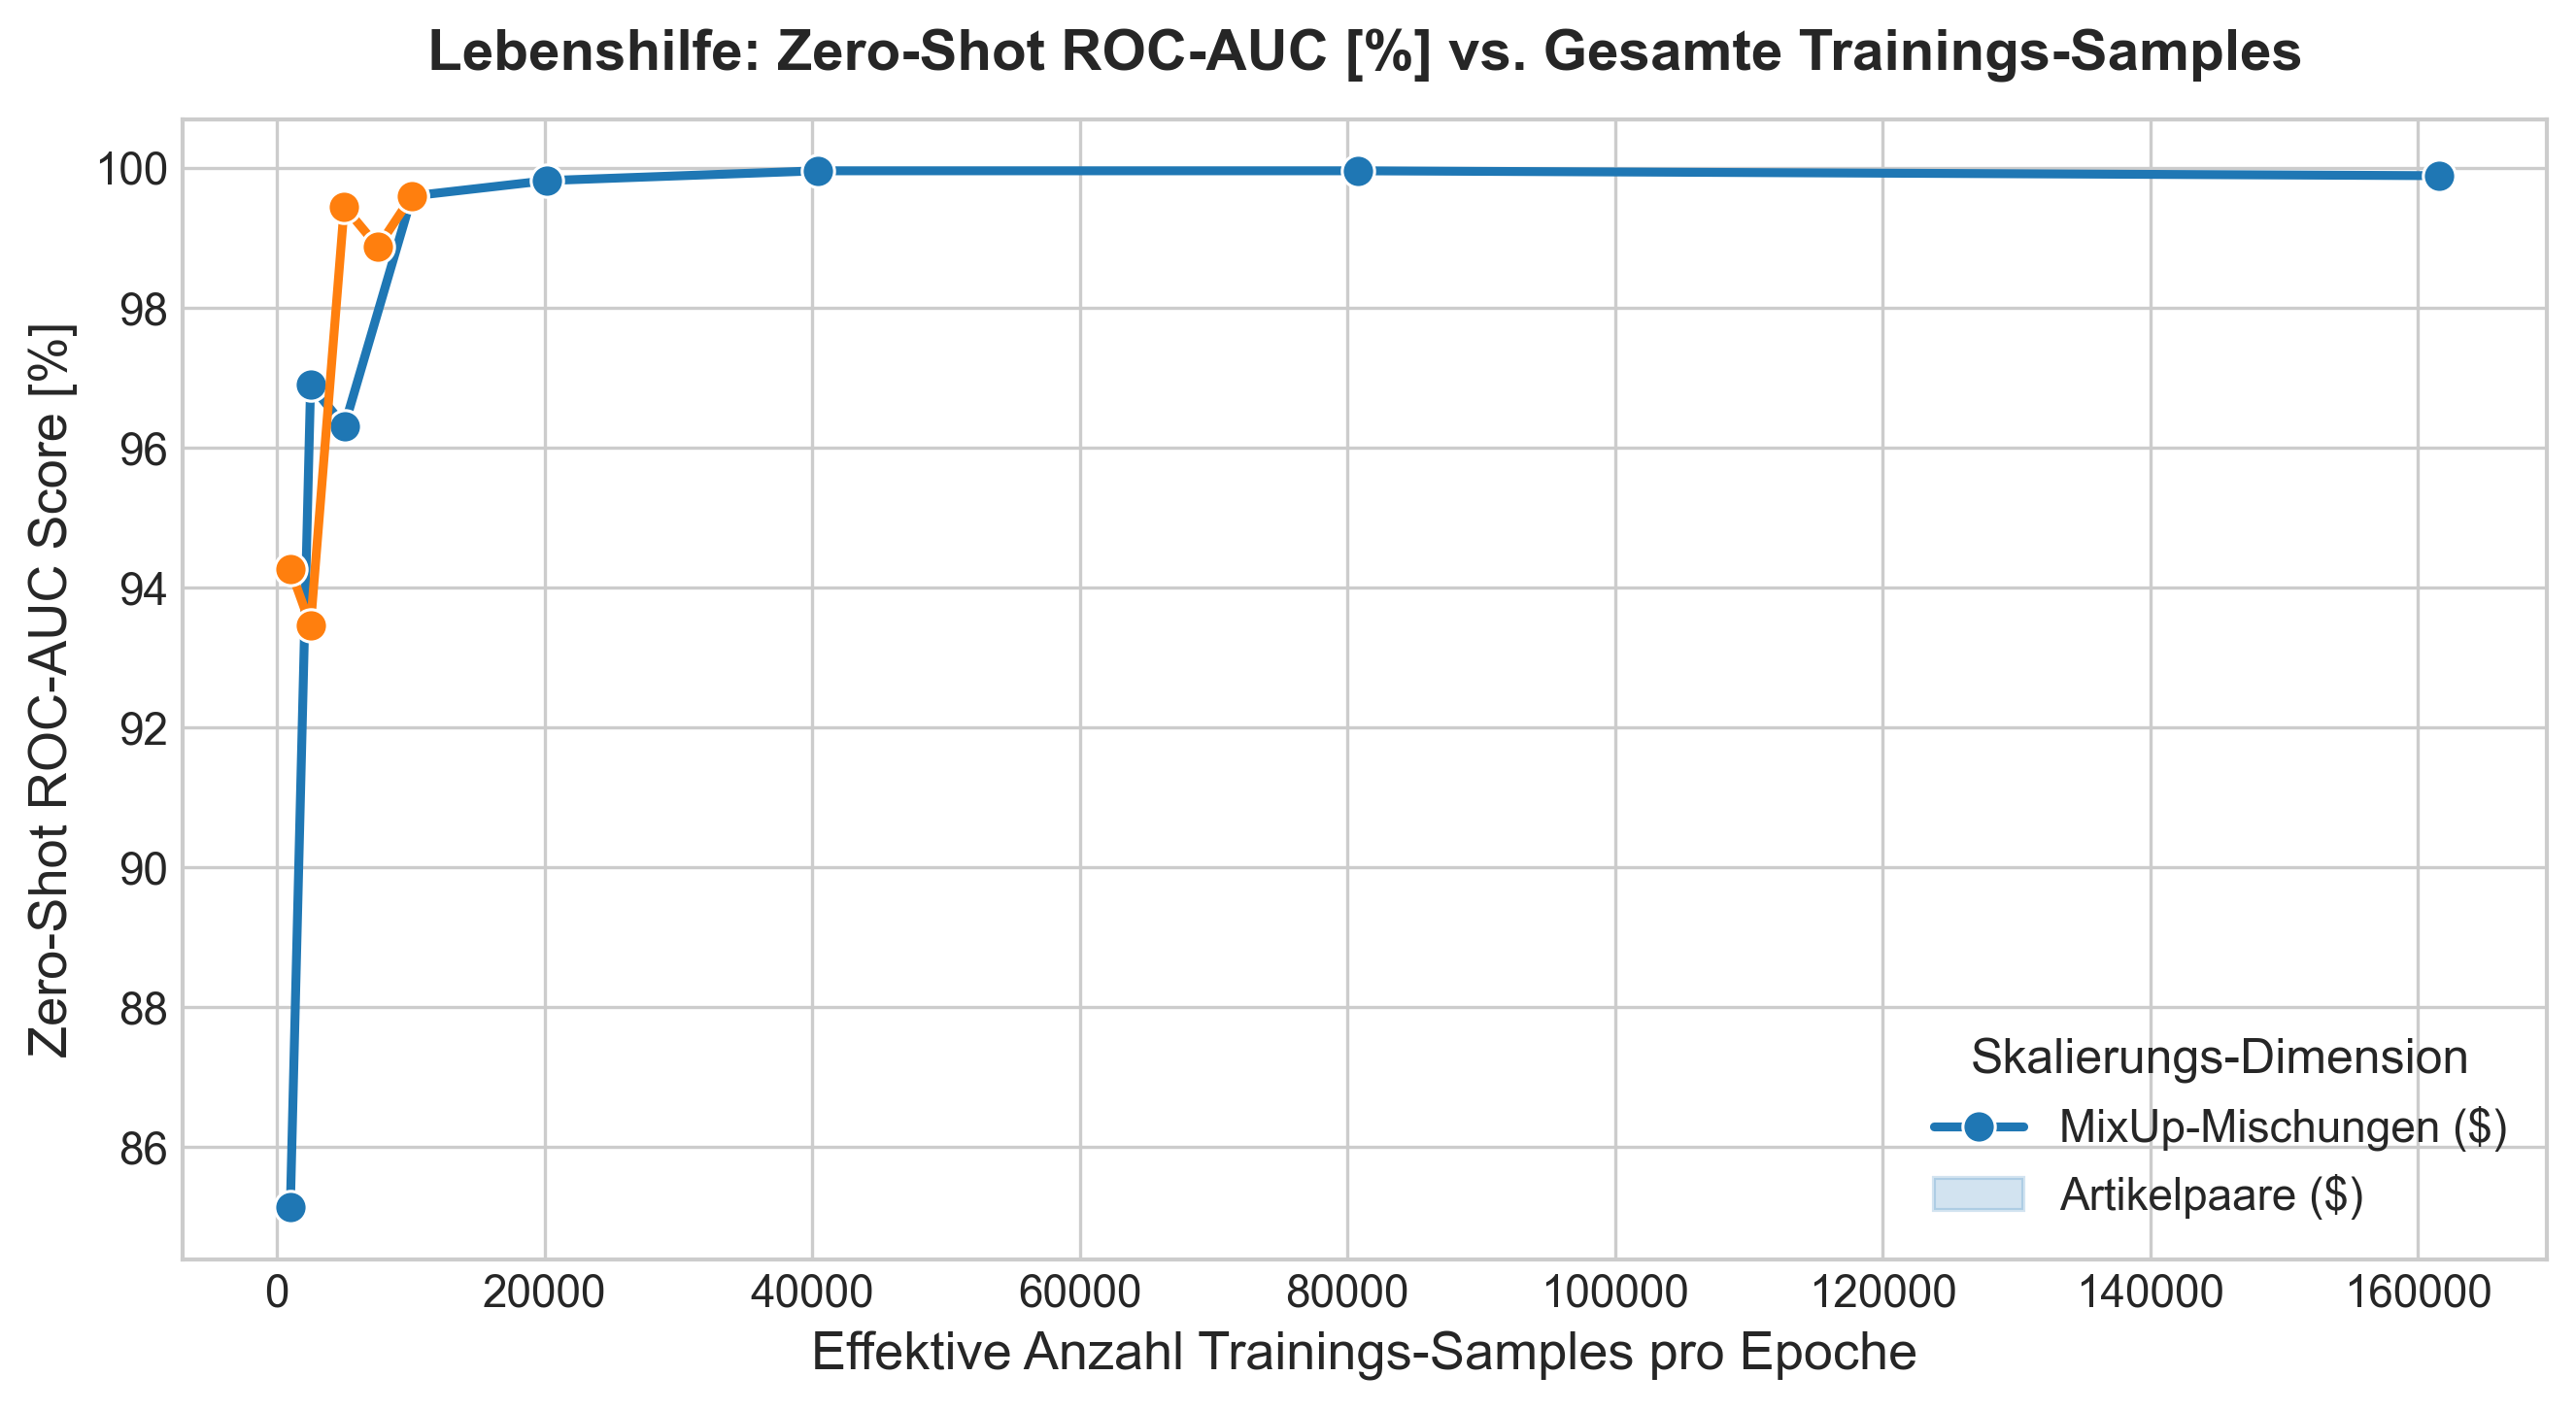

In [10]:
df_merged = df.merge(pd.read_csv(LH_SUMMARY_CSV), on="experiment_name", suffixes=("", "_lh")) if os.path.exists(LH_SUMMARY_CSV) else pd.DataFrame()

if not df_merged.empty:
    plt.figure(figsize=(9, 5))
    sns.lineplot(data=df_merged, x="total_train_samples", y="lh_auc", hue="experiment_group", marker='o', markersize=8, linewidth=2.2)
    plt.title("Lebenshilfe: Zero-Shot ROC-AUC [%] vs. Gesamte Trainings-Samples", pad=12, fontweight='bold')
    plt.xlabel("Effektive Anzahl Trainings-Samples pro Epoche")
    plt.ylabel("Zero-Shot ROC-AUC Score [%]")
    plt.legend(title="Skalierungs-Dimension", labels=["MixUp-Mischungen ($)", "Artikelpaare ($)"])
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "lh_auc_vs_total_samples.png"), dpi=300)
    plt.show()

## 6.4 Lebenshilfe Trainingsdauer vs. Zero-Shot MAE


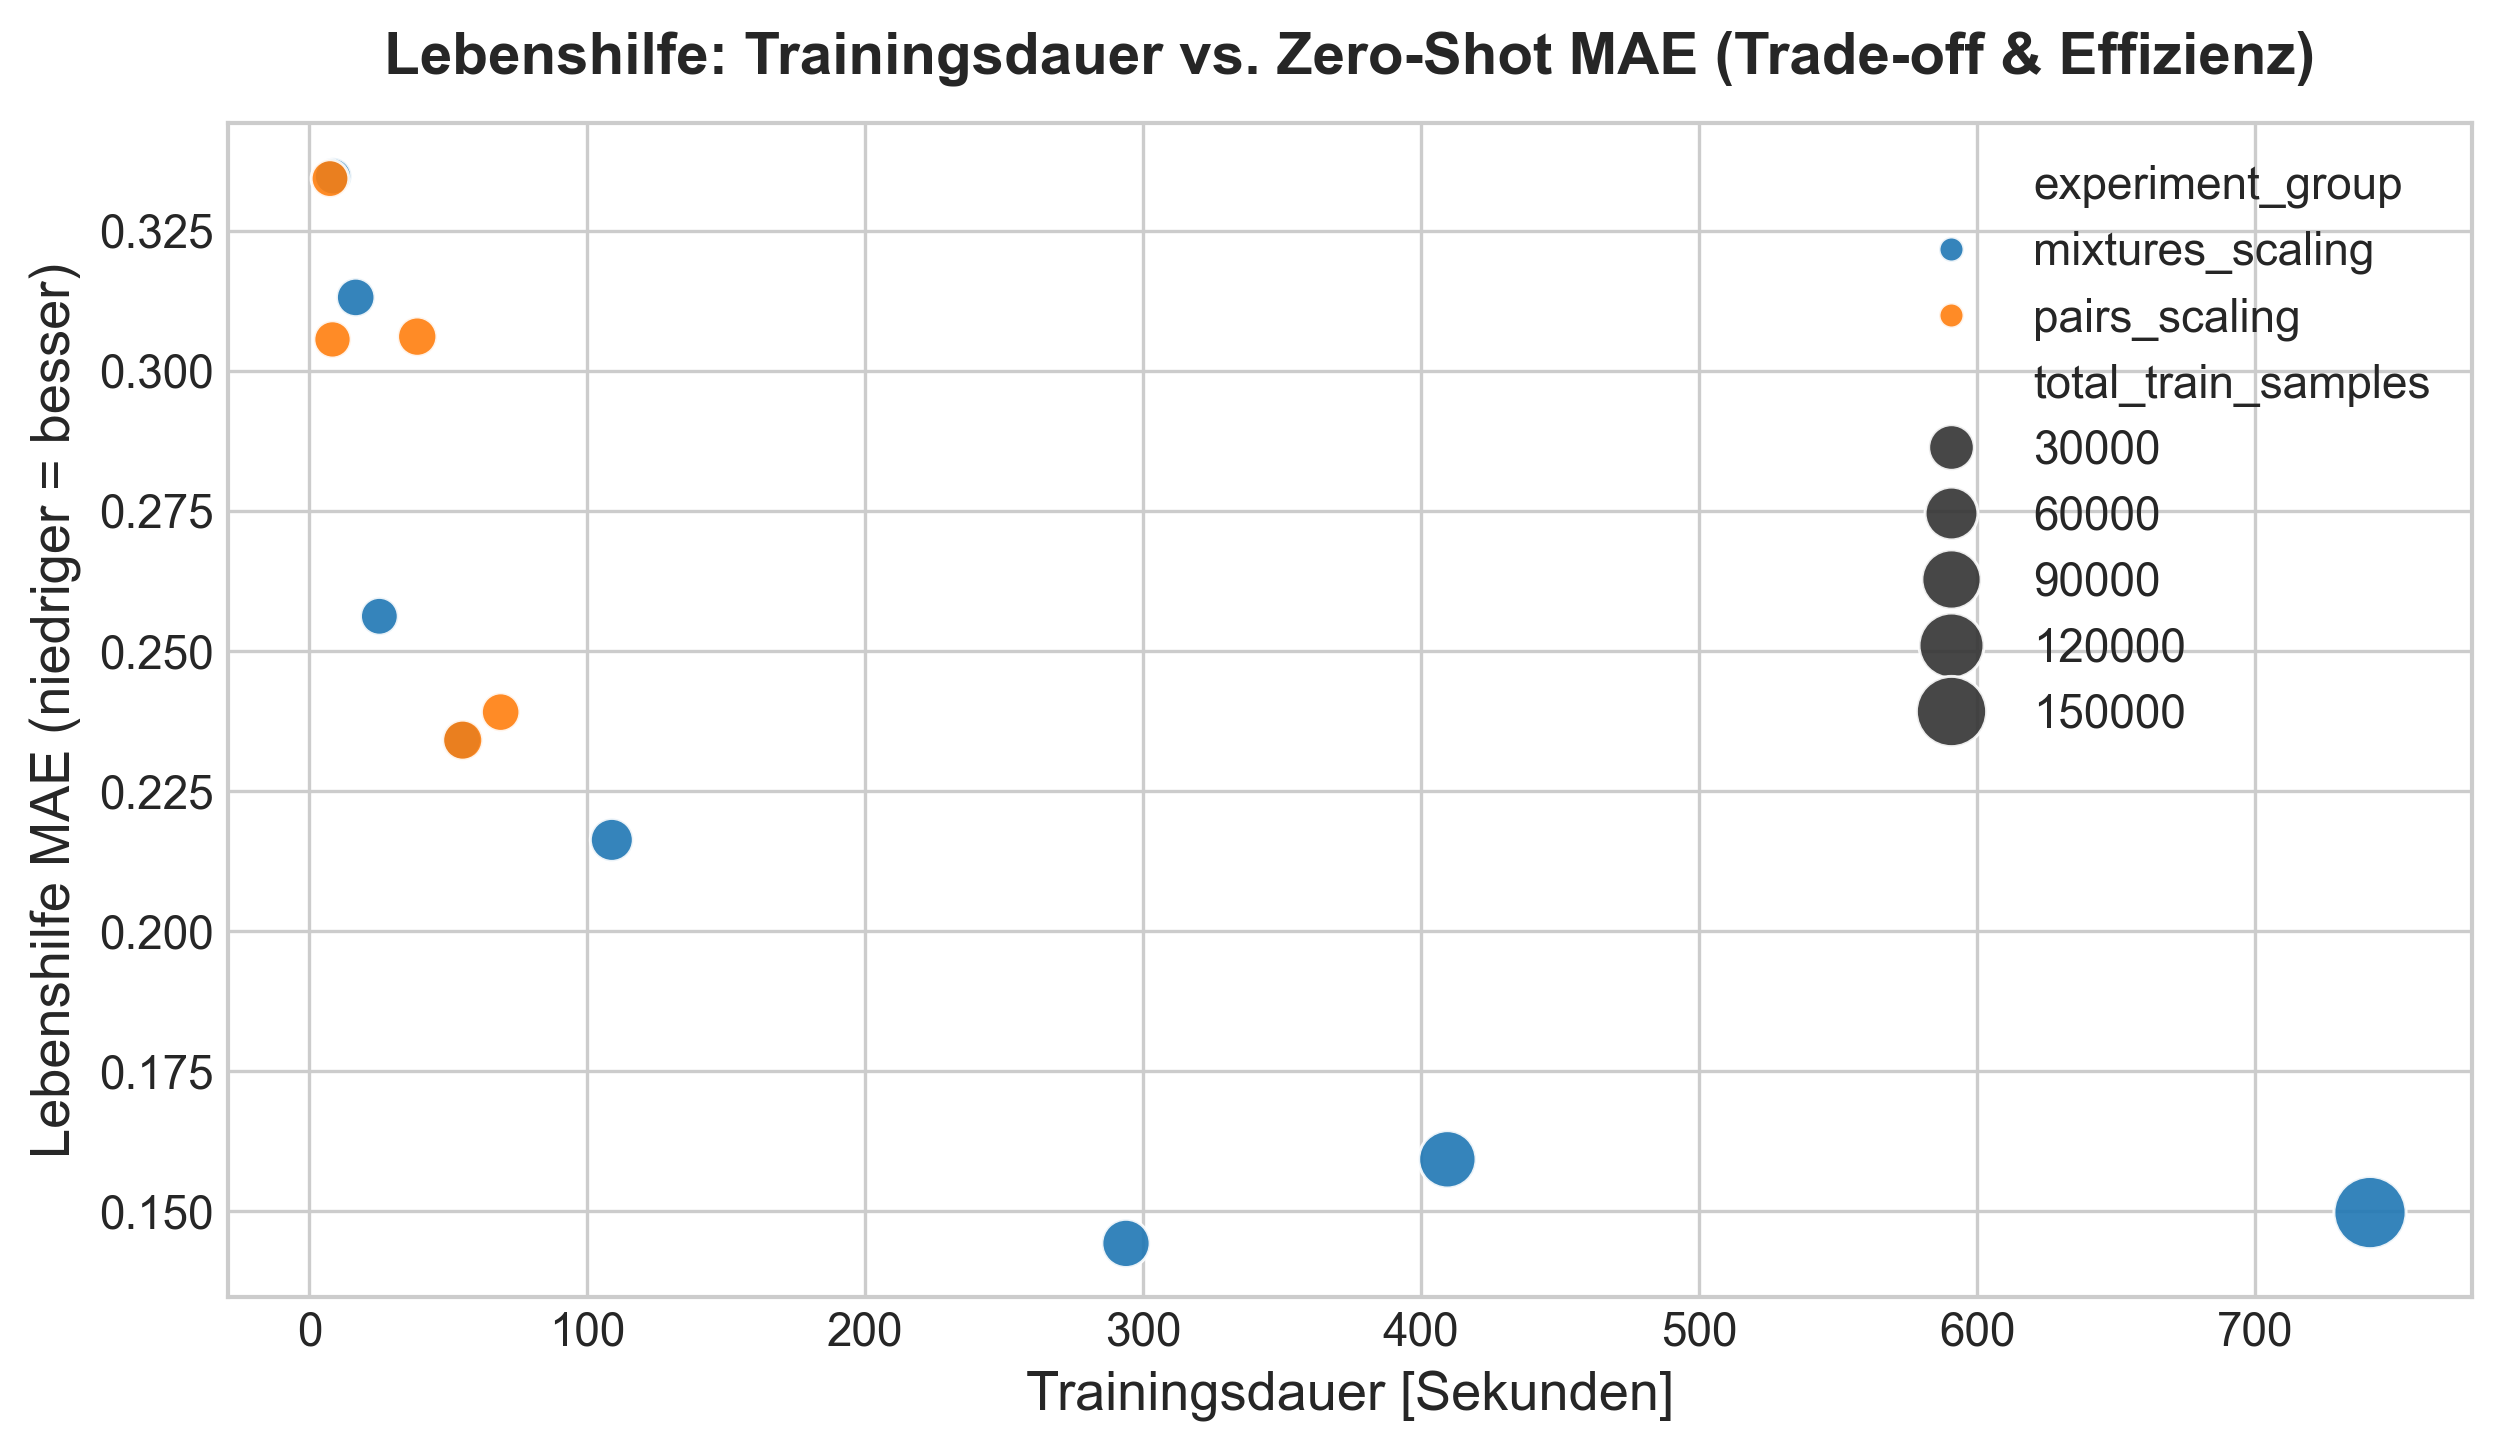

In [11]:
if not df_merged.empty:
    plt.figure(figsize=(8.5, 5))
    sns.scatterplot(
        data=df_merged,
        x="training_time_seconds",
        y="lh_mae",
        hue="experiment_group",
        size="total_train_samples",
        sizes=(80, 300),
        alpha=0.9
    )
    plt.title("Lebenshilfe: Trainingsdauer vs. Zero-Shot MAE (Trade-off & Effizienz)", pad=12, fontweight='bold')
    plt.xlabel("Trainingsdauer [Sekunden]")
    plt.ylabel("Lebenshilfe MAE (niedriger = besser)")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "lh_training_time_vs_mae.png"), dpi=300)
    plt.show()